In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_squared_error, r2_score

# Set premium aesthetics
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 7)

In [2]:
# Load the salary dataset
df = pd.read_csv('salary.csv')
print("📊 Dataset Sample:")
print(df.head())

# Using consistent variable names (Uppercase X for features)
# Using 'Level ' for X and 'Salary' for y
X = df[['Level ']].values
y = df['Salary'].values

📊 Dataset Sample:
            Position  Level   Salary
0   Business Analyst       1   45000
1  Junior Consultant       2   50000
2  Senior Consultant       3   60000
3            Manager       4   80000
4     Country Manger       5  110000


In [3]:
# Transform features to Polynomial (Degree 4 works well for this non-linear salary trend)
poly = PolynomialFeatures(degree=4)
X_poly = poly.fit_transform(X)

# Initialize and train the Linear Regression model
model = LinearRegression()
model.fit(X_poly, y)

print("✅ Polynomial model trained successfully.")

✅ Polynomial model trained successfully.


c:\Users\GOPIKA RAVEENDRAN\Desktop\Gopz\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128176 (\N{MONEY BAG}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


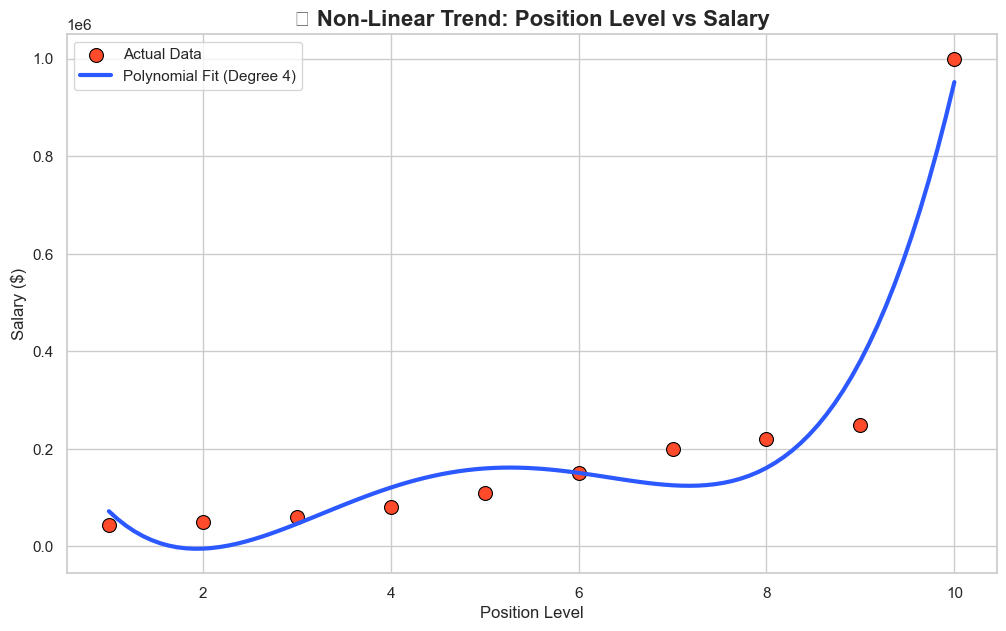

In [4]:
# Visualize the data and the polynomial fit
plt.figure(figsize=(12, 7))

# Actual data points
sns.scatterplot(x=df['Level '], y=df['Salary'], color='#ff4b2b', s=100, label='Actual Data', edgecolor='black')

# Generate points for the smooth curve
X_range = np.linspace(X.min(), X.max(), 100).reshape(-1, 1)
X_range_poly = poly.transform(X_range)
y_poly_pred = model.predict(X_range_poly)

plt.plot(X_range, y_poly_pred, color='#2b58ff', linewidth=3, label='Polynomial Fit (Degree 4)')

plt.title('💰 Non-Linear Trend: Position Level vs Salary', fontsize=16, fontweight='bold')
plt.xlabel('Position Level', fontsize=12)
plt.ylabel('Salary ($)', fontsize=12)
plt.legend()
plt.show()

In [5]:
# Model Evaluation
y_pred = model.predict(X_poly)
mse = mean_squared_error(y, y_pred)
r2 = r2_score(y, y_pred)

print(f"Overall R² Score: {r2:.4f}")
print(f"Mean Squared Error: {mse:.2f}")

Overall R² Score: 0.9502
Mean Squared Error: 3643560606.06


In [6]:
# Custom Prediction Function with User Input
def predict_salary(level):
    level_poly = poly.transform([[level]])
    prediction = model.predict(level_poly)[0]
    print(f"\n🔮 Prediction for Position Level {level}:")
    print(f"Estimated Salary: ${prediction:,.2f}")

# Input from User
try:
    user_level = float(input("Enter position level (e.g., 6.5 for halfway between Region Manager and Partner): "))
    predict_salary(user_level)
except ValueError:
    print("❌ Invalid input! Please enter a numeric value for the position level.")


🔮 Prediction for Position Level 5.0:
Estimated Salary: $159,953.38
